In [3]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Global plotting style: increase text sizes across all figures in this notebook.
plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
})

In [4]:
# ---- Core configuration (edit these first) ----
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR
BINARY = REPO_ROOT / "iron" / "operators" / "mul_bench" / "mul_bench_parallel_test"
BENCH_DIR = BINARY.parent

SIZE_GPU = 1 << 20
SIZE_NPU = 1 << 20
ITERS_GPU = 1
ITERS_NPU = 1
REPEATS = 3

NPU_COLUMNS = 8
NPU_CHANNELS = 2
NPU_TILE_SZ = 8192

RUN_GPU = True
RUN_NPU = True

print(f"Binary: {BINARY} (exists: {BINARY.exists()})")

Binary: /home/steven/gpu_bench/IRON/iron/operators/mul_bench/mul_bench_parallel_test (exists: True)


In [5]:
def artifact_stem(size_npu, r, num_columns=NPU_COLUMNS, num_channels=NPU_CHANNELS, tile_size=NPU_TILE_SZ):
    return f"MulBench_sz{size_npu}_c{num_columns}_ch{num_channels}_t{tile_size}_R{r}_npu2"


def ensure_npu_artifacts(r, size_npu=None):
    """Compile NPU xclbin/bin for this (size, r) if not already present."""
    if size_npu is None:
        size_npu = SIZE_NPU
    stem  = artifact_stem(size_npu, r)
    build = REPO_ROOT / "build"
    if (build / f"{stem}.xclbin").exists() and (build / f"{stem}.bin").exists():
        return
    print(f"  Compiling NPU artifact for R={r}...", end=" ", flush=True)
    result = subprocess.run(
        [
            sys.executable,
            "iron/operators/mul_bench/run_mul_bench_npu.py",
            "--size",         str(size_npu),
            "--r",            str(r),
            "--num-columns",  str(NPU_COLUMNS),
            "--num-channels", str(NPU_CHANNELS),
            "--tile-size",    str(NPU_TILE_SZ),
        ],
        cwd=str(REPO_ROOT),
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"NPU compilation failed for R={r}, size={size_npu}:\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    print("done")


def run_bench(r, size_gpu=None, size_npu=None, iters_gpu=None, iters_npu=None, run_gpu=None, run_npu=None, repeats=1):
    if size_gpu  is None: size_gpu  = SIZE_GPU
    if size_npu  is None: size_npu  = SIZE_NPU
    if iters_gpu is None: iters_gpu = ITERS_GPU
    if iters_npu is None: iters_npu = ITERS_NPU
    if run_gpu   is None: run_gpu   = RUN_GPU
    if run_npu   is None: run_npu   = RUN_NPU

    cmd = [
        str(BINARY),
        "--r",         str(r),
        "--size-gpu",  str(size_gpu),
        "--size-npu",  str(size_npu),
        "--iters-gpu", str(iters_gpu),
        "--iters-npu", str(iters_npu),
        "--repeats",   str(repeats),
        "--json",
    ]
    if not run_gpu:
        cmd.append("--no-gpu")
    if not run_npu:
        cmd.append("--no-npu")
    result = subprocess.run(cmd, cwd=str(BENCH_DIR), capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"Binary failed (exit {result.returncode}):\n"
            + (result.stderr[-500:] if result.stderr else "(no stderr)")
        )
    last_line = result.stdout.strip().splitlines()[-1]
    return json.loads(last_line)


## Run Your Sweep (Edit and Execute)

Start small first, then scale up.

Example:
- set `R_VALUES`
- run one or more sweep helpers
- call a plotting helper

In [6]:
total_batches = 100 #Total number of batches that will be split amongst the gpu or npu
repeats      = 10 #number of runs the data will be averaged over for each R, will run the number of batches specified in total_batches for each run
R_VALUES = np.unique(np.round(np.logspace(0, np.log10(2000), 50)).astype(int)).tolist()  # AI = R/2

In [ ]:
npu_points      = []
# ── NPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        if RUN_NPU:
            ensure_npu_artifacts(r)
        datan = run_bench(r, iters_npu=total_batches, run_gpu=False, run_npu=True, repeats=repeats)
        n = datan.get("npu")
        if n:
            npu_points.append((n["arith_intensity"], n["tflops"]))

            print(f"NPU {n['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"NPU BW {n['bandwidth_gbps']:.2f} GB/s")
        else:
            print("no NPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(npu_points)} NPU points.")

[1/43] R=    1  AI=0.50 FLOPs/Byte  

NPU 0.0151 TFLOPS  NPU BW 30.19 GB/s
[2/43] R=    2  AI=1.00 FLOPs/Byte  NPU 0.0303 TFLOPS  NPU BW 30.30 GB/s
[3/43] R=    3  AI=1.50 FLOPs/Byte  NPU 0.0458 TFLOPS  NPU BW 30.52 GB/s
[4/43] R=    4  AI=2.00 FLOPs/Byte  NPU 0.0594 TFLOPS  NPU BW 29.72 GB/s
[5/43] R=    5  AI=2.50 FLOPs/Byte  NPU 0.0741 TFLOPS  NPU BW 29.64 GB/s
[6/43] R=    6  AI=3.00 FLOPs/Byte  NPU 0.0909 TFLOPS  NPU BW 30.29 GB/s
[7/43] R=    8  AI=4.00 FLOPs/Byte  NPU 0.1221 TFLOPS  NPU BW 30.53 GB/s
[8/43] R=    9  AI=4.50 FLOPs/Byte  NPU 0.1368 TFLOPS  NPU BW 30.41 GB/s
[9/43] R=   10  AI=5.00 FLOPs/Byte  NPU 0.1515 TFLOPS  NPU BW 30.29 GB/s
[10/43] R=   12  AI=6.00 FLOPs/Byte  NPU 0.1820 TFLOPS  NPU BW 30.34 GB/s
[11/43] R=   14  AI=7.00 FLOPs/Byte  NPU 0.2064 TFLOPS  NPU BW 29.48 GB/s
[12/43] R=   16  AI=8.00 FLOPs/Byte  NPU 0.2435 TFLOPS  NPU BW 30.44 GB/s
[13/43] R=   19  AI=9.50 FLOPs/Byte  NPU 0.2875 TFLOPS  NPU BW 30.26 GB/s
[14/43] R=   22  AI=11.00 FLOPs/Byte  NPU 0.3323 TFLOPS  NPU BW 30.21 GB/s
[15/43] 

In [ ]:
gpu_points      = []
# ── GPU sweep ─────────────────────────────────────────────────────────────────
for idx, r in enumerate(R_VALUES):
    print(f"[{idx+1}/{len(R_VALUES)}] R={r:5d}  AI={r/2:.2f} FLOPs/Byte", end="  ", flush=True)
    try:
        datag = run_bench(r, iters_gpu=total_batches, run_gpu=True, run_npu=False, repeats=repeats)
        g = datag.get("gpu")
        if g:
            gpu_points.append((g["arith_intensity"], g["tflops"]))
            print(f"GPU {g['tflops']:.4f} TFLOPS", end="  ", flush=True)
            print(f"GPU BW {g['bandwidth_gbps']:.2f} GB/s")
        else:
            print("no GPU result")
    except Exception as exc:
        print(f"FAILED: {exc}")

print(f"\nCollected {len(gpu_points)} GPU points.")

[1/43] R=    1  AI=0.50 FLOPs/Byte  GPU 0.0380 TFLOPS  GPU BW 75.95 GB/s
[2/43] R=    2  AI=1.00 FLOPs/Byte  GPU 0.0739 TFLOPS  GPU BW 73.95 GB/s
[3/43] R=    3  AI=1.50 FLOPs/Byte  GPU 0.1154 TFLOPS  GPU BW 76.96 GB/s
[4/43] R=    4  AI=2.00 FLOPs/Byte  GPU 0.1485 TFLOPS  GPU BW 74.24 GB/s
[5/43] R=    5  AI=2.50 FLOPs/Byte  GPU 0.1923 TFLOPS  GPU BW 76.93 GB/s
[6/43] R=    6  AI=3.00 FLOPs/Byte  GPU 0.2228 TFLOPS  GPU BW 74.28 GB/s
[7/43] R=    8  AI=4.00 FLOPs/Byte  GPU 0.3020 TFLOPS  GPU BW 75.49 GB/s
[8/43] R=    9  AI=4.50 FLOPs/Byte  GPU 0.3477 TFLOPS  GPU BW 77.27 GB/s
[9/43] R=   10  AI=5.00 FLOPs/Byte  GPU 0.3829 TFLOPS  GPU BW 76.58 GB/s
[10/43] R=   12  AI=6.00 FLOPs/Byte  GPU 0.4559 TFLOPS  GPU BW 75.99 GB/s
[11/43] R=   14  AI=7.00 FLOPs/Byte  GPU 0.5254 TFLOPS  GPU BW 75.06 GB/s
[12/43] R=   16  AI=8.00 FLOPs/Byte  GPU 0.5849 TFLOPS  GPU BW 73.11 GB/s
[13/43] R=   19  AI=9.50 FLOPs/Byte  GPU 0.7264 TFLOPS  GPU BW 76.47 GB/s
[14/43] R=   22  AI=11.00 FLOPs/Byte  GPU 0.837

In [ ]:
# specifications for the roofline model, used when use_measured_points=False in bench_with_batch_bias
gpu_perf =  7500
npu_perf =  6400
gpu_mem = 74.5
npu_mem = 30
total_mem = 74.5

def bench_with_batch_bias(rs_values, npu_batch_bias=0, use_measured_points=True):
    """
    npu_batch_bias > 0  => give a few more batches to NPU
    npu_batch_bias < 0  => give a few fewer batches to NPU
    """
    if use_measured_points:
        gpu_lookup = {round(p[0] * 2): p[1] for p in gpu_points}
        npu_lookup = {round(p[0] * 2): p[1] for p in npu_points}
    points = []
    for idx, r in enumerate(rs_values):
        ai = r / 2.0
        try:
            # Same baseline split logic as gpu_npu_sweep.
            if use_measured_points:
                gpu_tf = gpu_lookup.get(r)
                npu_tf = npu_lookup.get(r)
                if gpu_tf is None:
                    raise ValueError(f"No measured GPU point for R={r} — run GPU sweep first with matching R_VALUES")
                if npu_tf is None:
                    raise ValueError(f"No measured NPU point for R={r} — run NPU sweep first with matching R_VALUES")
                gpu_need = gpu_tf * 1000 / ai
                npu_need = npu_tf * 1000 / ai
                mem_cap = min(total_mem, gpu_need + npu_need)
            else:
                gpu_need = min(gpu_perf / ai, gpu_mem)
                npu_need = min(npu_perf / ai, npu_mem)
                mem_cap = min(total_mem, gpu_need + npu_need)

            base_gpu_batches_max = int(total_batches * (gpu_need / max(mem_cap, 1e-12)))
            base_npu_batches_min = total_batches - base_gpu_batches_max
            max_npu_batches = int(total_batches * (npu_need / max(mem_cap, 1e-12)))
            if base_npu_batches_min == 0:
                base_npu_batches_min = 1
                base_gpu_batches_max = total_batches - 1

            # Apply controlled bias to batch distribution.
            if npu_batch_bias > 0:
                npu_batches = int(np.clip(max_npu_batches + npu_batch_bias, 1, total_batches - 1))
                gpu_batches = total_batches - npu_batches
            elif npu_batch_bias < 0:
                npu_batches = int(np.clip(base_npu_batches_min + npu_batch_bias, 1, total_batches - 1))
                gpu_batches = total_batches - npu_batches
            else:
                npu_batches = int(np.clip(base_npu_batches_min + npu_batch_bias, 1, total_batches - 1))
                gpu_batches = total_batches - npu_batches
            data = run_bench(r, iters_gpu=gpu_batches, iters_npu=npu_batches, repeats=repeats)
            tflops = data.get("combined_tflops")
            points.append((ai, tflops, gpu_batches, npu_batches))

            msg = (
                f"[{idx+1}/{len(rs_values)}] R={r:5d} AI={ai:7.2f} "
                f"GPU={gpu_batches:3d} NPU={npu_batches:3d}"
            )
            if tflops is not None:
                msg += f" -> {tflops:.4f} TFLOPS, Combined Bandwidth: {tflops*1000/ai:.2f} GB/s"
            else:
                msg += " -> no result"
            print(msg)
        except Exception as exc:
            print(f"[{idx+1}/{len(rs_values)}] R={r:5d} FAILED: {exc}")
            points.append((ai, None, None, None))
    return points

measured_more_npu_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=+int(np.floor(total_batches/10)), use_measured_points=True)
measured_less_npu_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=-int(np.floor(total_batches/10)), use_measured_points=True)
measured_baseline_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=0, use_measured_points=True)


[1/43] R=    1 AI=   0.50 GPU= 51 NPU= 49 -> 0.0273 TFLOPS, Combined Bandwidth: 54.62 GB/s
[2/43] R=    2 AI=   1.00 GPU= 52 NPU= 48 -> 0.0552 TFLOPS, Combined Bandwidth: 55.22 GB/s
[3/43] R=    3 AI=   1.50 GPU= 52 NPU= 48 -> 0.0826 TFLOPS, Combined Bandwidth: 55.06 GB/s
[4/43] R=    4 AI=   2.00 GPU= 50 NPU= 50 -> 0.1062 TFLOPS, Combined Bandwidth: 53.10 GB/s
[5/43] R=    5 AI=   2.50 GPU= 51 NPU= 49 -> 0.1355 TFLOPS, Combined Bandwidth: 54.22 GB/s
[6/43] R=    6 AI=   3.00 GPU= 51 NPU= 49 -> 0.1659 TFLOPS, Combined Bandwidth: 55.30 GB/s
[7/43] R=    8 AI=   4.00 GPU= 50 NPU= 50 -> 0.2103 TFLOPS, Combined Bandwidth: 52.56 GB/s
[8/43] R=    9 AI=   4.50 GPU= 50 NPU= 50 -> 0.2425 TFLOPS, Combined Bandwidth: 53.89 GB/s
[9/43] R=   10 AI=   5.00 GPU= 50 NPU= 50 -> 0.2656 TFLOPS, Combined Bandwidth: 53.12 GB/s
[10/43] R=   12 AI=   6.00 GPU= 51 NPU= 49 -> 0.3241 TFLOPS, Combined Bandwidth: 54.02 GB/s
[11/43] R=   14 AI=   7.00 GPU= 50 NPU= 50 -> 0.3725 TFLOPS, Combined Bandwidth: 53.21 GB

In [ ]:
def to_arrays(points):
    valid = [p for p in points if p[1] is not None]
    if not valid:
        return np.array([]), np.array([])
    return np.array([p[0] for p in valid]), np.array([p[1] for p in valid])


ai_measured_base, t_measured_base = to_arrays(measured_baseline_pts)
ai_measured_more, t_measured_more = to_arrays(measured_more_npu_pts)
ai_measured_less, t_measured_less = to_arrays(measured_less_npu_pts)

# Build aligned GPU/NPU throughput arrays at the same AI points as measured baseline.
gpu_ai_pts = np.array([p[0] for p in gpu_points], dtype=float)
gpu_tf_pts = np.array([p[1] for p in gpu_points], dtype=float)
npu_ai_pts = np.array([p[0] for p in npu_points], dtype=float)
npu_tf_pts = np.array([p[1] for p in npu_points], dtype=float)

if len(ai_measured_base) == 0 or len(gpu_ai_pts) == 0 or len(npu_ai_pts) == 0:
    measured_roofline = np.array([])
else:
    gpu_ref = np.interp(ai_measured_base, gpu_ai_pts, gpu_tf_pts)
    npu_ref = np.interp(ai_measured_base, npu_ai_pts, npu_tf_pts)
    measured_roofline = np.minimum(ai_measured_base * total_mem / 1000.0, gpu_ref + npu_ref)

print("\nSummary:")
if len(t_measured_base):
    print(f"Baseline mean TFLOPS: {t_measured_base.mean():.4f}")
if len(t_measured_base):
    print(f"Measured Baseline mean TFLOPS: {t_measured_base.mean():.4f}")
if len(t_measured_more):
    print(f"More-NPU mean TFLOPS: {t_measured_more.mean():.4f}")
if len(t_measured_less):
    print(f"Less-NPU mean TFLOPS: {t_measured_less.mean():.4f}")
    # Normalize GPU/NPU contributions by hetero roofline (avoid undefined P1/P2/P_het).


if len(ai_measured_base) == 0 or len(measured_roofline) == 0:
    P1_max = np.array([])
    P2_max = np.array([])
    P1_min = np.array([])
    P2_min = np.array([])
else:
    P1 = np.asarray(gpu_ref, dtype=float)   # GPU throughput at baseline AI points
    P2 = np.asarray(npu_ref, dtype=float)   # NPU throughput at baseline AI points
    P_het = measured_roofline  # Heterogeneous roofline at baseline AI points

    P1_max = np.minimum(P1 / P_het, 1.0)
    P2_max = np.minimum(P2 / P_het, 1.0)

    # Lower-bound complements
    P1_min = np.maximum(0.0, 1.0 - P2_max)
    P2_min = np.maximum(0.0, 1.0 - P1_max)

    #actual contributions
    P1_contrib = np.minimum(P1 / P_het, 0.99)
    P2_contrib = np.maximum(0.01, 1.0 - P1_max)



plt.figure(figsize=(11, 6))


plt.scatter(ai_measured_base, measured_roofline, color="green", s = 6, alpha=1, label="Measured Roofline Model")
plt.scatter(ai_measured_base, t_measured_base, color="purple", s = 6, alpha=1, label="Measured Baseline split")
plt.scatter(gpu_ai_pts, gpu_tf_pts, color="royalblue", s = 6, alpha=0.7, label="GPU Roofline (Measured)")
plt.scatter(npu_ai_pts, npu_tf_pts, color="darkorange", s = 6, alpha=0.7, label="NPU Roofline (Measured)")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
#plt.xscale("log")
#plt.yscale("log")
plt.ylabel("Throughput (TFLOPS)")
#plt.title("GPU+NPU Combined Roofline Using Measured NPU and GPU rooflines")

plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig("gpu_npu_roofline_measured.pdf", dpi=300)
plt.show()

plt.figure(figsize=(11, 6)) 
#want to plot P1_max, P2_max, P1_min, P2_min as stacked area plot to show the range of possible GPU/NPU contributions under the hetero roofline constraint.
plt.fill_between(ai_measured_base, P1_min, P1_max, color="royalblue", alpha=0.5, label="GPU contribution range")
plt.fill_between(ai_measured_base, P2_min, P2_max, color="darkorange", alpha=0.5, label="NPU contribution range")
plt.plot(ai_measured_base, P1_contrib, color="royalblue", linewidth=1.5, label="GPU contribution")
plt.plot(ai_measured_base, P2_contrib, color="darkorange", linewidth=1.5, label="NPU contribution")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Normalized Throughput Contribution")
#plt.title("Possible GPU/NPU Contribution Ranges Under Heterogeneous Roofline Constraint")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig("gpu_npu_measured_contribution_ranges.pdf", dpi=300)
plt.show()

NameError: name 'measured_baseline_pts' is not defined

In [ ]:
# Log-style version of the percent-difference plot.
# Percent differences cross zero, so symlog preserves the sign while still giving log-like spacing.

if len(ai_measured_base) and len(t_measured_base):
    base_t = np.maximum(np.asarray(t_measured_base, dtype=float), 1e-12)

    more_t = np.asarray(t_measured_more, dtype=float) if len(t_measured_more) else np.array([])
    less_t = np.asarray(t_measured_less, dtype=float) if len(t_measured_less) else np.array([])

    more_ai = np.asarray(ai_measured_more, dtype=float) if len(ai_measured_more) else np.array([])
    less_ai = np.asarray(ai_measured_less, dtype=float) if len(ai_measured_less) else np.array([])

    if len(more_ai):
        more_t = np.interp(ai_measured_base, more_ai, more_t)
    if len(less_ai):
        less_t = np.interp(ai_measured_base, less_ai, less_t)

    more_pct = 100.0 * (more_t / base_t - 1.0) if len(more_t) else np.array([])
    less_pct = 100.0 * (less_t / base_t - 1.0) if len(less_t) else np.array([])

    plt.figure(figsize=(13, 7))
    if len(more_pct):
        plt.plot(ai_measured_base, more_pct, color="tab:blue", linestyle="--", marker="o", markersize=2.5, linewidth=1.0, label="More NPU vs Baseline (%)")
    if len(less_pct):
        plt.plot(ai_measured_base, less_pct, color="tab:orange", linestyle=":", marker="o", markersize=2.5, linewidth=1.0, label="Less NPU vs Baseline (%)")

    plt.axhline(0, color="gray", linewidth=1.0)
    plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
    plt.ylabel("Percent Difference from Baseline (%)")
    #plt.title("Bias Impact: Percent Difference vs Baseline (log-style)")
    plt.grid(True, which="both", alpha=0.3, linestyle="--")
    plt.legend()
    plt.tight_layout()
    plt.savefig("gpu_npu_measured_bias_percent_diff.pdf", dpi=300)
    plt.show()
else:
    print("Run the baseline, more-NPU, and less-NPU cells first.")

NameError: name 'ai_measured_base' is not defined

In [ ]:
# specifications for the roofline model, used when use_measured_points=False in bench_with_batch_bias
gpu_perf =  7500
npu_perf =  5000
gpu_mem = 74.5
npu_mem = 30
total_mem = 75

model_more_npu_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=+int(np.floor(total_batches/10)), use_measured_points=False)
model_less_npu_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=-int(np.floor(total_batches/10)), use_measured_points=False)
model_baseline_pts = bench_with_batch_bias(R_VALUES, npu_batch_bias=0, use_measured_points=False)

[1/43] R=    1 AI=   0.50 GPU= 50 NPU= 50 -> 0.0263 TFLOPS, Combined Bandwidth: 52.63 GB/s
[2/43] R=    2 AI=   1.00 GPU= 50 NPU= 50 -> 0.0528 TFLOPS, Combined Bandwidth: 52.83 GB/s
[3/43] R=    3 AI=   1.50 GPU= 50 NPU= 50 -> 0.0800 TFLOPS, Combined Bandwidth: 53.33 GB/s
[4/43] R=    4 AI=   2.00 GPU= 50 NPU= 50 -> 0.1064 TFLOPS, Combined Bandwidth: 53.20 GB/s
[5/43] R=    5 AI=   2.50 GPU= 50 NPU= 50 -> 0.1314 TFLOPS, Combined Bandwidth: 52.58 GB/s
[6/43] R=    6 AI=   3.00 GPU= 50 NPU= 50 -> 0.1585 TFLOPS, Combined Bandwidth: 52.84 GB/s
[7/43] R=    8 AI=   4.00 GPU= 50 NPU= 50 -> 0.2122 TFLOPS, Combined Bandwidth: 53.04 GB/s
[8/43] R=    9 AI=   4.50 GPU= 50 NPU= 50 -> 0.2317 TFLOPS, Combined Bandwidth: 51.49 GB/s
[9/43] R=   10 AI=   5.00 GPU= 50 NPU= 50 -> 0.2657 TFLOPS, Combined Bandwidth: 53.13 GB/s
[10/43] R=   12 AI=   6.00 GPU= 50 NPU= 50 -> 0.3141 TFLOPS, Combined Bandwidth: 52.35 GB/s
[11/43] R=   14 AI=   7.00 GPU= 50 NPU= 50 -> 0.3713 TFLOPS, Combined Bandwidth: 53.05 GB


Summary:
Baseline mean TFLOPS: 4.4467
Measured Baseline mean TFLOPS: 4.4467
More-NPU mean TFLOPS: 3.7249
Less-NPU mean TFLOPS: 4.1737


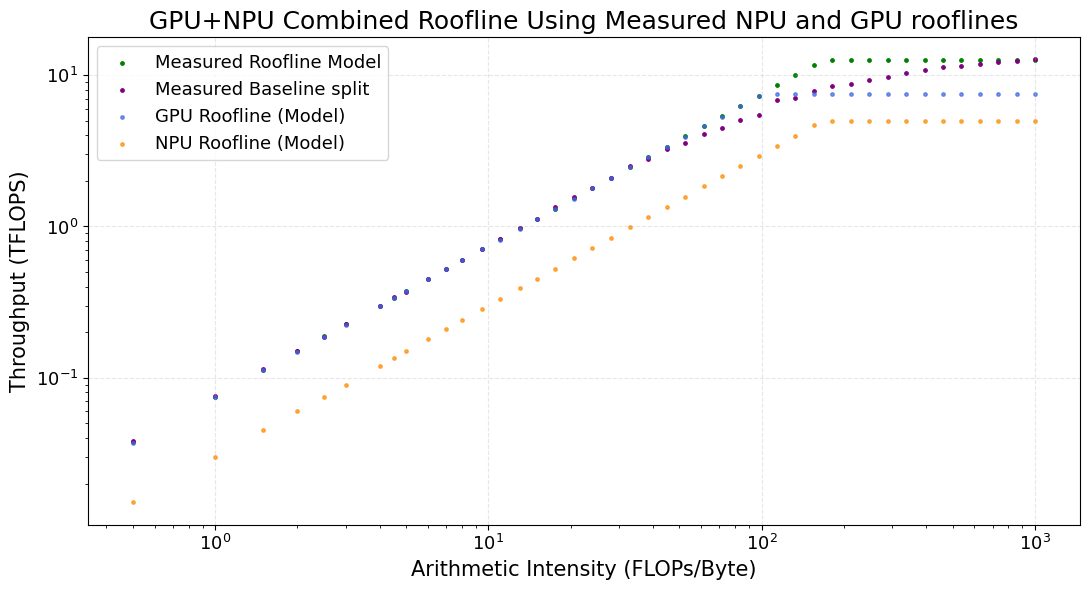

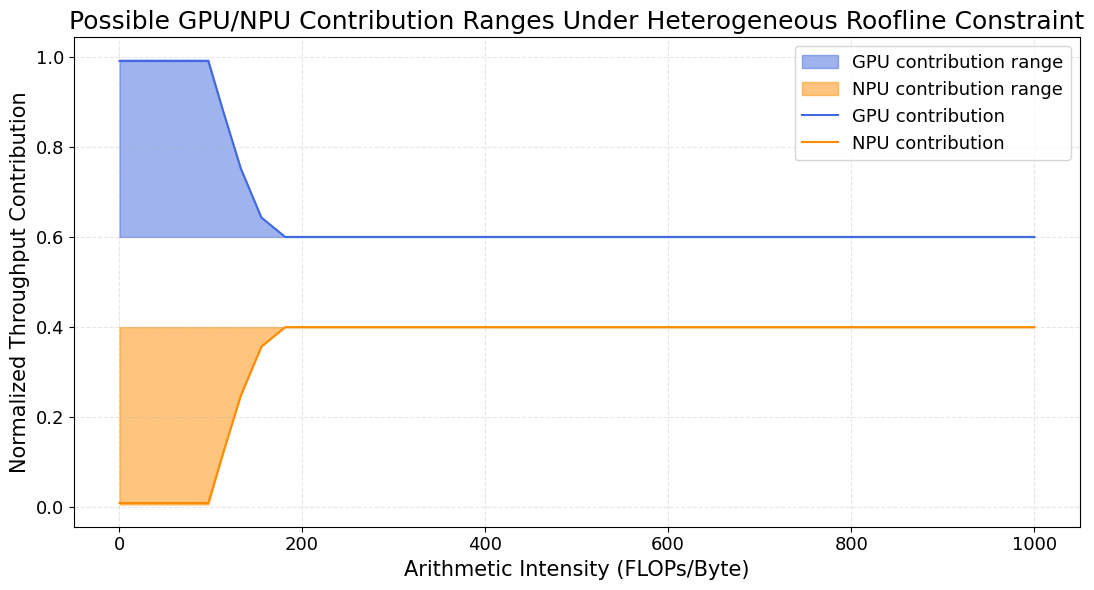

In [ ]:


ai_model_base, t_model_base = to_arrays(model_baseline_pts)
ai_model_more, t_model_more = to_arrays(model_more_npu_pts)
ai_model_less, t_model_less = to_arrays(model_less_npu_pts)

# Build aligned GPU/NPU throughput arrays at the same AI points as measured baseline.
gpu_ai_pts = np.array([p[0] for p in gpu_points], dtype=float)
gpu_tf_pts = np.array([p[1] for p in gpu_points], dtype=float)
npu_ai_pts = np.array([p[0] for p in npu_points], dtype=float)
npu_tf_pts = np.array([p[1] for p in npu_points], dtype=float)

gpu_roofline = np.minimum(gpu_ai_pts * gpu_mem/1000, gpu_perf/1000)
npu_roofline = np.minimum(npu_ai_pts * npu_mem/1000, npu_perf/1000)
hetero_roofline = np.minimum(ai_model_base * total_mem/1000, gpu_roofline + npu_roofline)


print("\nSummary:")
if len(t_model_base):
    print(f"Baseline mean TFLOPS: {t_model_base.mean():.4f}")
if len(t_model_base):
    print(f"Measured Baseline mean TFLOPS: {t_model_base.mean():.4f}")
if len(t_model_more):
    print(f"More-NPU mean TFLOPS: {t_model_more.mean():.4f}")
if len(t_model_less):
    print(f"Less-NPU mean TFLOPS: {t_model_less.mean():.4f}")
    # Normalize GPU/NPU contributions by hetero roofline (avoid undefined P1/P2/P_het).


if len(ai_measured_base) == 0 or len(measured_roofline) == 0:
    P1_max = np.array([])
    P2_max = np.array([])
    P1_min = np.array([])
    P2_min = np.array([])
else:
    P1 = gpu_roofline  # GPU throughput at baseline AI points
    P2 = npu_roofline  # NPU throughput at baseline AI points
    P_het = hetero_roofline  # Heterogeneous roofline at baseline AI points

    P1_max = np.minimum(P1 / P_het, 1.0)
    P2_max = np.minimum(P2 / P_het, 1.0)

    # Lower-bound complements
    P1_min = np.maximum(0.0, 1.0 - P2_max)
    P2_min = np.maximum(0.0, 1.0 - P1_max)

    #actual contributions
    P1_contrib = np.minimum(P1 / P_het, 0.99)
    P2_contrib = np.maximum(0.01, 1.0 - P1_max)



plt.figure(figsize=(11, 6))


plt.scatter(ai_measured_base, hetero_roofline, color="green", s = 6, alpha=1, label="Measured Roofline Model")
plt.scatter(ai_measured_base, t_measured_base, color="purple", s = 6, alpha=1, label="Measured Baseline split")
plt.scatter(gpu_ai_pts, gpu_roofline, color="royalblue", s = 6, alpha=0.7, label="GPU Roofline (Model)")
plt.scatter(npu_ai_pts, npu_roofline, color="darkorange", s = 6, alpha=0.7, label="NPU Roofline (Model)")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Throughput (TFLOPS)")
plt.title("GPU+NPU Combined Roofline Using Measured NPU and GPU rooflines")

plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig("gpu_npu_roofline_model.png", dpi=300)
plt.show()

plt.figure(figsize=(11, 6)) 
#want to plot P1_max, P2_max, P1_min, P2_min as stacked area plot to show the range of possible GPU/NPU contributions under the hetero roofline constraint.
plt.fill_between(ai_measured_base, P1_min, P1_max, color="royalblue", alpha=0.5, label="GPU contribution range")
plt.fill_between(ai_measured_base, P2_min, P2_max, color="darkorange", alpha=0.5, label="NPU contribution range")
plt.plot(ai_measured_base, P1_contrib, color="royalblue", linewidth=1.5, label="GPU contribution")
plt.plot(ai_measured_base, P2_contrib, color="darkorange", linewidth=1.5, label="NPU contribution")
plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
plt.ylabel("Normalized Throughput Contribution")
plt.title("Possible GPU/NPU Contribution Ranges Under Heterogeneous Roofline Constraint")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig("gpu_npu_model_contribution_ranges.png", dpi=300)
plt.show()

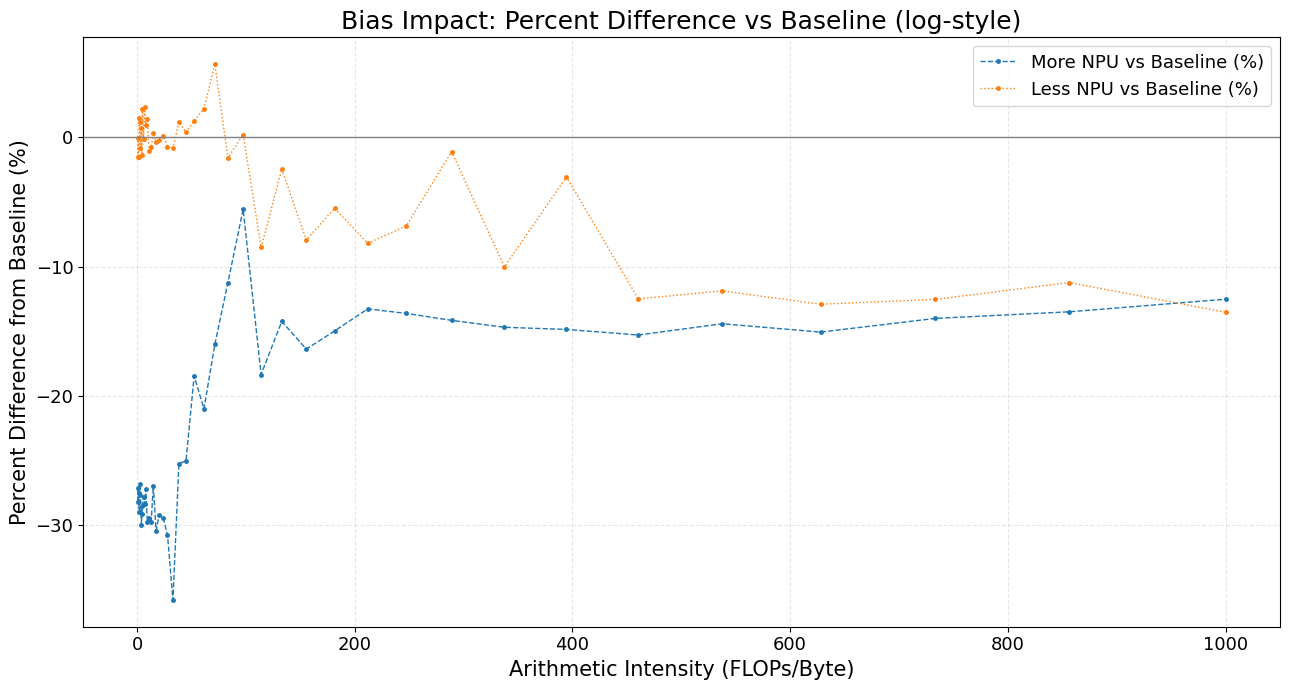

In [ ]:
# Log-style version of the percent-difference plot.
# Percent differences cross zero, so symlog preserves the sign while still giving log-like spacing.

if len(ai_measured_base) and len(t_measured_base):
    base_t = np.maximum(np.asarray(t_measured_base, dtype=float), 1e-12)

    more_t = np.asarray(t_measured_more, dtype=float) if len(t_measured_more) else np.array([])
    less_t = np.asarray(t_measured_less, dtype=float) if len(t_measured_less) else np.array([])

    more_ai = np.asarray(ai_measured_more, dtype=float) if len(ai_measured_more) else np.array([])
    less_ai = np.asarray(ai_measured_less, dtype=float) if len(ai_measured_less) else np.array([])

    if len(more_ai):
        more_t = np.interp(ai_measured_base, more_ai, more_t)
    if len(less_ai):
        less_t = np.interp(ai_measured_base, less_ai, less_t)

    more_pct = 100.0 * (more_t / base_t - 1.0) if len(more_t) else np.array([])
    less_pct = 100.0 * (less_t / base_t - 1.0) if len(less_t) else np.array([])

    plt.figure(figsize=(13, 7))
    if len(more_pct):
        plt.plot(ai_measured_base, more_pct, color="tab:blue", linestyle="--", marker="o", markersize=2.5, linewidth=1.0, label="More NPU vs Baseline (%)")
    if len(less_pct):
        plt.plot(ai_measured_base, less_pct, color="tab:orange", linestyle=":", marker="o", markersize=2.5, linewidth=1.0, label="Less NPU vs Baseline (%)")

    plt.axhline(0, color="gray", linewidth=1.0)
    plt.xlabel("Arithmetic Intensity (FLOPs/Byte)")
    plt.ylabel("Percent Difference from Baseline (%)")
    plt.title("Bias Impact: Percent Difference vs Baseline (log-style)")
    plt.grid(True, which="both", alpha=0.3, linestyle="--")
    plt.legend()
    plt.tight_layout()
    plt.savefig("gpu_npu_measured_bias_percent_diff.png", dpi=300)
    plt.show()
else:
    print("Run the baseline, more-NPU, and less-NPU cells first.")